In [1]:
from py_files.setup import *
setup_notebook()

# `Inequality measures`

Plotting the evolution in the CIT against the gini and the labour share.

*`1. Get data`*

In [2]:
# 1. empirical tax path (CIT)
_, tau_t, _, _ = shocks.perm_tc_emp(tail=0, normalized=False)

# 1.2 drop last obs
df_ = pd.DataFrame(tau_t)
df  = df_.reset_index(names='TID')
df['TID'] += df.TID + 2000
df = df[(df['TID'] <= 2024) & (df['TID'] >= 2000)]


# 2. labour share
NABP36 = DstApi('NABP36')

params_ls = {
    'table': 'NABP36',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'PRISENHED', 'values': ['V']},     # current prices (m. DKK)
        {'code': 'Tid', 'values': ['*']},
        {'code': 'BRANCHE', 'values': ['V']},
        {'code': 'TRANSAKT', 'values': ['B1GD','D1D']}
        ]
}

# 2.2 get and clean
df_ls_ = NABP36.get_data(params=params_ls)
df_ls_['INDHOLD'] = pd.to_numeric(df_ls_['INDHOLD'], errors='coerce')

df_ls = df_ls_.pivot_table(
    index=['TID','BRANCHE'],
    columns='TRANSAKT',
    values='INDHOLD'
).reset_index()

df_ls = df_ls.rename(columns={
    'B.1g Gross value added'   : 'GVA',
    'D.1 Compensation of employees': 'e_comp',
})

# 2.3 compute labor share by industry
df_ls['labor_share'] = df_ls['e_comp'] / df_ls['GVA'] * 100
df_ls = df_ls[df_ls['TID'] >= 2000]


# 3. Gini, fix comma to dot
gini = pd.read_csv('0_raw_data/IFOR41.csv', sep=';', decimal=',')
gini = gini[gini['TID'] >= 2000]

`*also intangibles?*`

In [3]:
years = range(2000, 2024)
investment_timeseries = il.compute_investment_timeseries(
    years=years, 
    normalize_by_gdp=True  
)

Processing year 2000...
Processing year 2001...
Processing year 2002...
Processing year 2003...
Processing year 2004...
Processing year 2005...
Processing year 2006...
Processing year 2007...
Processing year 2008...
Processing year 2009...
Processing year 2010...
Processing year 2011...
Processing year 2012...
Processing year 2013...


*`2. Plot all`*

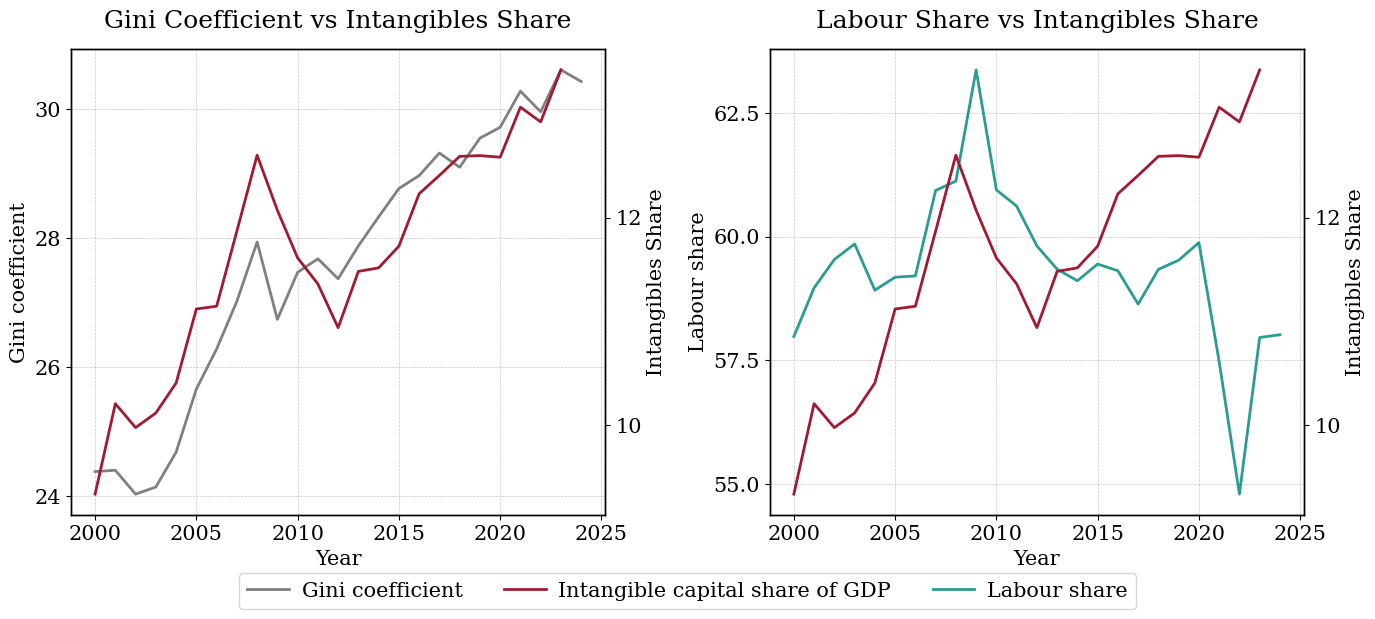

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel - Gini vs CIT
ax1_twin = ax1.twinx()
line1 = ax1.plot(gini.TID, gini.INDHOLD, label='Gini coefficient', linewidth=2, color='gray')
line2 = ax1_twin.plot(
    investment_timeseries.index, 
    investment_timeseries.intangible, 
    label='Intangible capital share of GDP', linewidth=2, color='#9E1B32')

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient")
ax1_twin.set_ylabel("Intangibles Share")
ax1.set_title("Gini Coefficient vs Intangibles Share", pad=15)
ax1.grid(True, which="both", linestyle="--", alpha=0.7, linewidth=0.5)
ax1.locator_params(axis='y', nbins=4)
ax1_twin.locator_params(axis='y', nbins=4)

# Right panel - Labour share vs CIT
ax2_twin = ax2.twinx()
line3 = ax2.plot(df_ls.TID, df_ls.labor_share, label='Labour share', linewidth=2, color='#2A9D8F')
line4 = ax2_twin.plot(
    investment_timeseries.index, 
    investment_timeseries.intangible, 
    label='CIT', linewidth=2, color='#9E1B32')

ax2.set_xlabel("Year")
ax2.set_ylabel("Labour share")
ax2_twin.set_ylabel("Intangibles Share")
ax2.set_title("Labour Share vs Intangibles Share", pad=15)
ax2.grid(True, which="both", linestyle="--", alpha=0.7, linewidth=0.5)
ax2.locator_params(axis='y', nbins=4)
ax2_twin.locator_params(axis='y', nbins=4)

# Collect all lines and labels
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]

# Create single legend below subplots
fig.legend(lines, labels, loc='lower center', ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)  
plt.savefig('0_output/correlation_arg.png')
plt.show()